# Free-Lunch 🍽️
### "Safe stocks beat risky ones" — so where's the catch?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free lunch?: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

One of finance's favourite anomalies: low-risk (low-beta) assets earn more *per unit of risk* than high-risk ones. The strategy that harvests it — betting against beta — has a famous Sharpe. The catch hides in one word: **leverage**. To make the safe-stock bet market-sized you have to borrow ~3×, and the bill for that borrowing is the whole premium.

> 📓 **Plain-language layer.** The leverage maths and the financing sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (free_lunch/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from free_lunch import data, strategy as st
assets, market = data.fetch_etf_panel()       # cache-first; built by examples/verify.py --fetch
gross, lev = st.bab_returns(assets, market, return_leverage=True)
mkt = st.market_monthly(market).loc[gross.index]


## The answer first 🎯

| The pitch | The catch |
|---|---|
| "Low-beta beats high-beta risk-adjusted" | Even **gross**, the book's Sharpe (0.47) is **below** just owning the market (0.59). |
| "A market-neutral free lunch" | It runs the safe leg at **2.8×** — borrowed money. |
| "Great Sharpe!" | Charge 5% to borrow and the strategy loses money. |

## 1 · The claim

Betting against beta (Frazzini & Pedersen 2014): leverage-constrained investors overpay for high-beta assets, so you can earn a premium by going **long low-beta (levered up to beta 1)** and **short high-beta**. Market-neutral, positive expected return.

## 2 · So what?

If true and tradable, it's a low-risk way to beat the market — the holy grail. But "levered up to beta 1" is doing enormous work in that sentence. We make the leverage explicit and price it.

## 3 · How would we even know?

Build the beta-neutral book on a liquid-ETF cross-section, measure the leverage the low-beta leg actually needs, then **charge realistic financing** and watch the Sharpe — and compare to simply owning the market.

In [2]:
print(f'Average leverage on the low-beta (long) leg: {lev:.2f}x')
rows={'BAB gross':st.summary(gross),'SPY (market)':st.summary(mkt)}
display(pd.DataFrame(rows).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))

Average leverage on the low-beta (long) leg: 2.78x


,cagr,sharpe,vol_ann,max_drawdown
BAB gross,0.081,0.472,0.216,-0.453
SPY (market),0.081,0.590,0.152,-0.508


## 4 · The teardown — price the leverage

Now sweep the cost of the borrowed 1.8× and watch the famous edge dissolve.

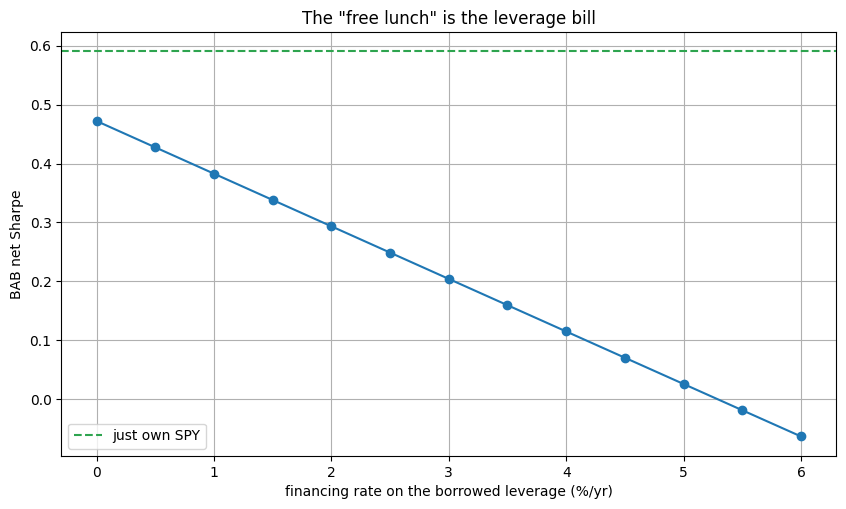

In [3]:
rates=np.linspace(0,0.06,13)
shp=[st.summary(st.bab_returns(assets,market,financing_ann=r,borrow_ann=r/6))['sharpe'] for r in rates]
fig,ax=plt.subplots()
ax.plot(rates*100, shp, marker='o')
ax.axhline(st.summary(mkt)['sharpe'],color='#2ea44f',ls='--',label='just own SPY')
ax.set_xlabel('financing rate on the borrowed leverage (%/yr)'); ax.set_ylabel('BAB net Sharpe')
ax.set_title('The "free lunch" is the leverage bill'); ax.legend(); plt.show()

**Read it plainly.** At a 0% borrow rate the line starts below "just own SPY" already — and every realistic borrow cost drags it lower, to zero and beyond. The premium was rent on leverage. (Same lesson as [Study 30 House-Edge](../../30-house-edge/).)

## 5 · The verdict

**Signal: Weak** — the tilt exists but doesn't beat the market gross. **Tradability: Mirage** — financing erases it. **Free lunch?: Busted** — you pay for it in borrow.

## 6 · Could you actually trade it?

Only if you can borrow ~1.8× of your capital cheaply and indefinitely — which retail can't, and which is precisely the constraint the anomaly claims to exploit in *others*. Charge yourself the same rate and the edge is gone.

## 7 · Going further 🚪

The quants notebook shows the 2.78× construction and the decay. Next: [Study 44 Growth-Spurt](../../44-growth-spurt/) — the asset-growth anomaly, the highest headline Sharpe on the vendor's list, on real balance-sheet data.